## Análise de comércio internacional do Ceará

Esse projeto tem por objetivo a geração de insights sobre movimentações para exportação de carga nos portos do Ceará.

Os dados são de disponibilidade pública e foram obtidos do site www.basedosdados.org.

Os comentários técnicos são feitos dentro de cada célula de código.

### Configurações gerais

In [2]:
#instalação e importação das bibliotecas necessárias

# para instalar as bibliotecas necessárias em ambiente virtual, basta colar a linha abaixo no terminal
# pip install -r requirements.txt

import os
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import basedosdados as bd #para conexão com a base de dados
from dotenv import load_dotenv #para ler o arquivo que contém o ID do projeto no google bigquery

In [3]:
#configuração do project ID
load_dotenv()

# O trecho abaixo lê de um outro arquivo o id do projeto. Por questões de segurança dos dados esse arquivo externo não será disponibilizado publicamente.
# Para mais informações sobre como replicar esse projeto consulte o arquivo README.md

project_id = os.getenv("google_id_do_projeto") #SUBSTITUA ESSE CÓDIGO PELO SEU ID PARA REPLICAR O PROJETO


### Principais destinos das exportações cearenses

Aqui entende-se quais são os principais parceiros comerciais das exportações. Essa análise visa identificar se há dependência de um país na economia do Estado.

In [4]:
query = """
SELECT 
    nomeclatura_pais.nome AS destino,  -- destino do produto
    nomeclatura_sh.nome_sh4_portugues AS produto,  -- nome do produto
    SUM(exportacao.valor_fob_dolar) AS valor_USD  -- Valor total das exportações (em dólares)

FROM `basedosdados.br_me_comex_stat.ncm_exportacao` AS exportacao 


-- esses joins são para traduzir o nome dos produtos. Necessário usar tabela intermediária on sh6 para tradução do código sh4
JOIN `basedosdados.br_bd_diretorios_mundo.nomenclatura_comum_mercosul` AS nomeclatura_mercosul_intermediario  
  ON exportacao.id_ncm = nomeclatura_mercosul_intermediario.id_ncm
JOIN `basedosdados.br_bd_diretorios_mundo.sistema_harmonizado` AS nomeclatura_sh 
  ON nomeclatura_mercosul_intermediario.id_sh6 = nomeclatura_sh.id_sh6

-- esse join é para traduzir a UF de origem e permitir selecionar apenas o estado do Ceará
LEFT JOIN (SELECT DISTINCT sigla,nome  FROM `basedosdados.br_bd_diretorios_brasil.uf`) AS diretorio_sigla_uf_ncm 
  ON exportacao.sigla_uf_ncm = diretorio_sigla_uf_ncm.sigla

-- esse join é para traduzir o nome dos países
JOIN `basedosdados.br_bd_diretorios_mundo.pais` AS nomeclatura_pais   
  ON exportacao.sigla_pais_iso3 = nomeclatura_pais.sigla_pais_iso3   

-- esse join serve para identificar a via de exportação e permitir a seleção apenas da via marítima
LEFT JOIN `basedosdados.br_me_comex_stat.dicionario` AS dic  
  ON exportacao.id_via = dic.chave
  AND dic.nome_coluna = 'id_via'
  AND dic.id_tabela = 'ncm_exportacao'

WHERE exportacao.ano BETWEEN 2015 AND 2025 -- limitador de 10 anos

GROUP BY produto, destino, diretorio_sigla_uf_ncm.nome, dic.valor

HAVING 
  diretorio_sigla_uf_ncm.nome = 'Ceará' -- limitador de exportações apenas do estado do Ceará 
  AND dic.valor = 'Maritima'  -- limitador de exportações via marítima

ORDER BY valor_USD DESC  -- Para organizar por ordem de valor total de vendas
"""

df = bd.read_sql(
    query,  # a query criada acima
    billing_project_id=project_id  # o id do projeto
)

Downloading: 100%|██████████|


In [5]:
# somar os valores de cada país para se ter um panorama geral
df_paises = df.groupby("destino")["valor_USD"].sum().reset_index()

# ordenar por valor total
df_paises=df_paises.sort_values(by="valor_USD", ascending=False) # ascending False para organizar por ordem decrescente

# formatar os valores do número para melhor visualização
df_paises["valor_USD"] = df_paises["valor_USD"] / 1_000_000


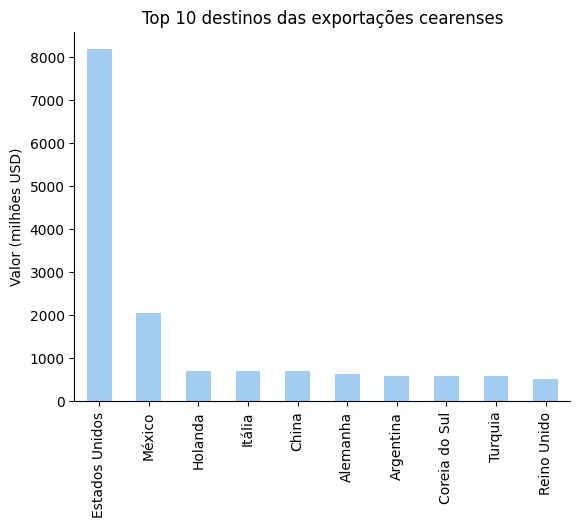

In [6]:
# plotar resultado em gráfico
ax = df_paises.head(10).plot(
    kind="bar",
    x="destino",
    y="valor_USD",
    legend=False,
    color='#A3CEF1'
)
# remover as linhas de cima e da direita da "caixa" em que o gráfico é criado
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title("Top 10 destinos das exportações cearenses")
plt.xlabel("")
plt.ylabel("Valor (milhões USD)")

plt.show()

Nota-se um claro destaque dos Estados Unidos como principal destino das exportações cearenses. Essa dominância sobre os demais países pode ser uma vulnerabilidade, uma vez que qualquer alteração no regime de comércio com esse país tem um grande impacto na economia estadual.

Devido ao resultado obtido através do gráfico, é valida uma investigação mais aprofundada sobre o que compõe esse volume de exportações para os Estados Unidos.

In [7]:
df_us = df[df["destino"]=="Estados Unidos"].copy() # novo df para selecionar apenas as exportações para EUA

df_us.head()

,destino,produto,valor_USD
0,Estados Unidos,Produtos semimanufacturados de ferro ou aço nã...,4078641563
2,Estados Unidos,"Outras ligas de aço, em lingotes ou outras for...",943806240
5,Estados Unidos,Partes reconhecíveis como destinadas às máquin...,444092779
6,Estados Unidos,Sumos de frutas (incluídos os mostos de uvas) ...,422288920
8,Estados Unidos,"Cocos, castanha do Brasil e castanha de caju, ...",363132063


O resultado acima indica dominância de dois produtos nas exportações direcionadas aos Estados Unidos. Abaixo um gráfico para destacar essa distância em relação aos demais produtos.

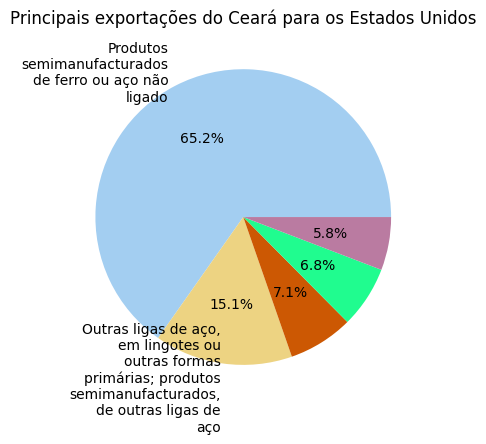

In [8]:

rotulos = df_us.head(2)["produto"].tolist() #pegando apenas os dois primeiros produtos com maior parcela
rotulos = [textwrap.fill(i, width =20) for i in rotulos] # para permitir quebrar as linhas dos nomes dos produtos
rotulos = rotulos + (['']*(len(df_us['produto'].head())-2)) # popular a lista de rotulos com string vazia para ter a mesma quantidade de elementos em relação ao gráfico

plt.pie( # gráfico de pizza
    x=df_us["valor_USD"].head(), 
    labels= rotulos,
    colors= ['#A3CEF1','#EDD382', '#CC5803', '#20FC8F', '#BA7BA1'],
    labeldistance=1.1, # controla distância do rótulo de dados
    textprops={'fontsize': 10}, # controla tamanho da fonte do rótulo de dados
    autopct="%1.1f%%", # inclui porcentagem de cada categoria
    pctdistance=0.60 # controla posição das porcentagens
)

plt.title("Principais exportações do Ceará para os Estados Unidos")
plt.xlabel("")
plt.ylabel("")

plt.show()


Nota-se fortes valores de exportação de produtos siderúrgicos, dominando quase 70% das transações para os Estados Unidos.

### Diferenças de carga entre os portos

O foco agora é entender as particularidades de cada porto. O estado do Ceará possui 2 portos, e essa análise vem identificar quais são as principais cargas de cada um. A finalidade é entender se há necessidades logísticas específicas de cada porto. Devido a estrutra da fonte de dados a identificação do porto de saída das mercadorias foi feita através do id da unidade da receita federeal que liberou a carga.

In [9]:
query = """ 
SELECT 
    dic_urf.valor AS porto_de_saida,
    nomeclatura_sh.nome_sh4_portugues AS categoria_do_produto, 
    IF (dic_urf.valor LIKE '%Fortaleza%' OR dic_urf.valor LIKE '%Pecem%', 'Sim', 'Não') AS saiu_do_ce, -- identificar produtos exportados no estado do CE
    SUM(exportacao.valor_fob_dolar) AS valor_total_usd  -- Valor total das exportações (em usd)

FROM `basedosdados.br_me_comex_stat.ncm_exportacao` AS exportacao 

-- esse join serve para traduzir o id da unidade da receita federal (id_urf) no nome do porto
JOIN `basedosdados.br_me_comex_stat.dicionario` AS dic_urf
    ON exportacao.id_urf = dic_urf.chave 
    AND dic_urf.nome_coluna = 'id_urf'
    AND dic_urf.id_tabela = 'ncm_exportacao'

-- esses joins são para traduzir o nome dos produtos. Necessário usar tabela intermediária on sh6 para tradução do código sh4
JOIN `basedosdados.br_bd_diretorios_mundo.nomenclatura_comum_mercosul` AS nomeclatura_mercosul_intermediario  
  ON exportacao.id_ncm = nomeclatura_mercosul_intermediario.id_ncm
JOIN `basedosdados.br_bd_diretorios_mundo.sistema_harmonizado` AS nomeclatura_sh 
  ON nomeclatura_mercosul_intermediario.id_sh6 = nomeclatura_sh.id_sh6

-- esse join é para traduzir a UF de origem dos proodutos e permitir selecionar apenas produtos feitos no estado do Ceará
JOIN (SELECT DISTINCT sigla,nome  FROM `basedosdados.br_bd_diretorios_brasil.uf`) AS diretorio_sigla_uf_ncm 
  ON exportacao.sigla_uf_ncm = diretorio_sigla_uf_ncm.sigla

-- esse join serve para identificar a via de exportação e permitir a seleção apenas da via marítima
JOIN `basedosdados.br_me_comex_stat.dicionario` AS dic  
  ON exportacao.id_via = dic.chave
  AND dic.nome_coluna = 'id_via'
  AND dic.id_tabela = 'ncm_exportacao'

WHERE exportacao.ano BETWEEN 2015 AND 2025 -- limitador de 10 anos
  AND diretorio_sigla_uf_ncm.nome = 'Ceará' -- limitador de exportações apenas do estado do Ceará 
  AND dic.valor = 'Maritima'  -- limitador de exportações via marítima

GROUP BY porto_de_saida, categoria_do_produto

ORDER BY valor_total_usd DESC  -- Para organizar por ordem de volume total de movimentação
"""
df_2 = bd.read_sql(
    query,  # a query criada acima
    billing_project_id=project_id  # o id do projeto
)

df_2.head(20)

Downloading: 100%|██████████|


,porto_de_saida,categoria_do_produto,saiu_do_ce,valor_total_usd
0,Alf - Fortaleza,Produtos semimanufacturados de ferro ou aço nã...,Sim,7654586930
1,Porto De Pecem,Produtos semimanufacturados de ferro ou aço nã...,Sim,1215729062
2,Alf - Fortaleza,"Outras ligas de aço, em lingotes ou outras for...",Sim,1028767450
3,Alf - Fortaleza,Partes reconhecíveis como destinadas às máquin...,Sim,607949142
4,Alf - Fortaleza,Outro calçado com sola exterior e parte superi...,Sim,449122901
5,Alf - Fortaleza,"Cocos, castanha do Brasil e castanha de caju, ...",Sim,437805651
6,Porto De Santos,Outro calçado com sola exterior e parte superi...,Não,357690889
7,Alf - Fortaleza,"Melões, melancias e papaias (mamões), frescos",Sim,344212092
8,Alf - Fortaleza,"Ceras vegetais (exceto triglicéridos), ceras d...",Sim,328336060
9,Alf - Fortaleza,Sumos de frutas (incluídos os mostos de uvas) ...,Sim,316033097


A primeira análise nesse dataset revelou que existem produtos produzidos no Ceará mas que são exportados por portos de outros estados. Apesar da intenção geral desse projeto ser a análise dos portos do Ceará, é interessante entender o quanto representam essas exportações em outros locais.

In [10]:
# dataset auxiliar, somando os valores exportados por portos dentre e fora do estado.
df_logistico = df_2.groupby("saiu_do_ce")['valor_total_usd'].sum().reset_index()

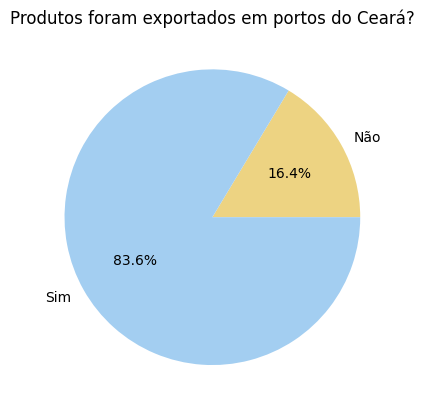

In [11]:
# plotar isso num gráfico de pizza pra visualizar melhor

labels = df_logistico['saiu_do_ce'].to_list() # transforma os valores das linhas dessa coluna em uma lista de strings para passar como labels

plt.pie(
    x=df_logistico['valor_total_usd'],
    labels = labels,
    colors = ['#EDD382', '#A3CEF1'],
    autopct="%1.1f%%" # inclui porcentagem de cada categoria
)
plt.title("Produtos foram exportados em portos do Ceará?")
plt.show()

Como a intenção dessa análise é estudar as cargas movimentadas nos portos do Ceará, os produtos que são escoados por portos de outros estados serão desconsiderados na próxima análise.

In [12]:
# remover as linhas onde o produto não saiu do Ceará

df_2.drop(df_2[df_2['saiu_do_ce']=='Não'].index, inplace=True)

In [13]:
# durante análise foi observado que é necessário padrozinar o nome dos portos para evitar duplicatas como alf - Fortaleza e porto de Fortaleza
# aqui se identifica as diferentes nomeclaturas usadas para os mesmos portos.

df_2['porto_de_saida'].unique()

array(['Alf - Fortaleza', 'Porto De Pecem', 'Irf - Porto De Pecem',
       'Porto De Fortaleza'], dtype=object)

In [14]:
# aqui foi necessário criar o filtro primeiro e depois aplicar dentro do loc porque quando aplicava direto no loc dava erro

# padronizar os valores para porto do pecém
filtro_pecem = df_2['porto_de_saida'].str.contains('pecem', # valor a ser buscado em qualquer posição da string
                                                    case=False, # não diferencia maiúsculas e minúsculas
                                                    na=False) # não preencher valores faltantes

df_2.loc[filtro_pecem,'porto_de_saida'] = 'Porto do Pecém' 


# padronizar os valores para porto de Fortaleza (porto do mucuripe)
filtro_fortaleza = df_2['porto_de_saida'].str.contains('fortaleza', 
                                                       case=False, 
                                                       na=False)

df_2.loc[filtro_fortaleza,'porto_de_saida'] = 'Porto de Fortaleza' 

In [15]:
# conferindo o resultado das padronizações
df_2['porto_de_saida'].unique()

array(['Porto de Fortaleza', 'Porto do Pecém'], dtype=object)

In [16]:
# tratamento de valores do total de exportação. Necessário para evitar problemas nos gráficos.
# a partir desse ponto os valores totais de exportção são exibidos em milhôes de dólares
df_2['valor_total_usd'] = round(df_2['valor_total_usd']/1_000_000, 2)

In [17]:
# finalmente, pode-se plotar quais os maiores valores de exportação de produtos em cada porto

#iniciando com o porto do Pecém
# criando dataframe só com exportações do pecém
df_2_pecem = df_2[df_2['porto_de_saida'] == 'Porto do Pecém'].copy()



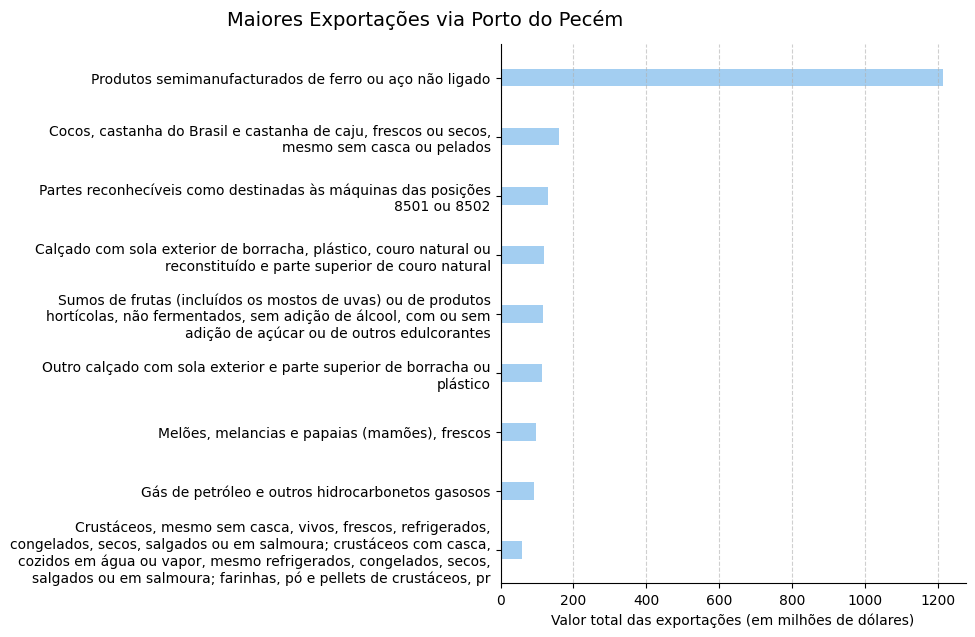

In [18]:
rotulos = df_2_pecem['categoria_do_produto'].head(10)
rotulos = [textwrap.fill(i, width =65) for i in rotulos] # para permitir quebrar as linhas dos nomes dos produtos

#plotando no gráfico para melhor visualização
plt.figure(figsize=(6, 7)) # tamanho da caixa da figura
plt.barh(
    rotulos,
    df_2_pecem['valor_total_usd'].head(10),
    color='#A3CEF1',
    height=0.30
)
plt.gca().invert_yaxis() # necessário para a correta ordem decrescente dos valores.

# usar esse método para título garante mais controle
plt.suptitle('Maiores Exportações via Porto do Pecém', 
             fontsize=14, 
            x=0, #garante que o titulo fique no meio da caixa
            y=0.93
            )

# remover as linhas de cima e da direita da "caixa" em que o gráfico é criado
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.6) # adicionar o grid para melhor visuzaliação
plt.yticks(fontsize=10) #controla o tamanho da fonte dos rótulos de dados

plt.xlabel("Valor total das exportações (em milhões de dólares)")

plt.show()

Nota-se um forte destaque para produtos siderúrgicos. Há ainda outros produtos destinados à indústria (partes de máquinas e combustíveis), calçados e alimentos (incluindo alimentos que necessitam de refrigeração).

In [19]:
# análise do porto de Fortaleza

# criando dataframe só com exportações de Fortaleza
df_2_fortaleza = df_2[df_2['porto_de_saida'] == 'Porto de Fortaleza'].copy()

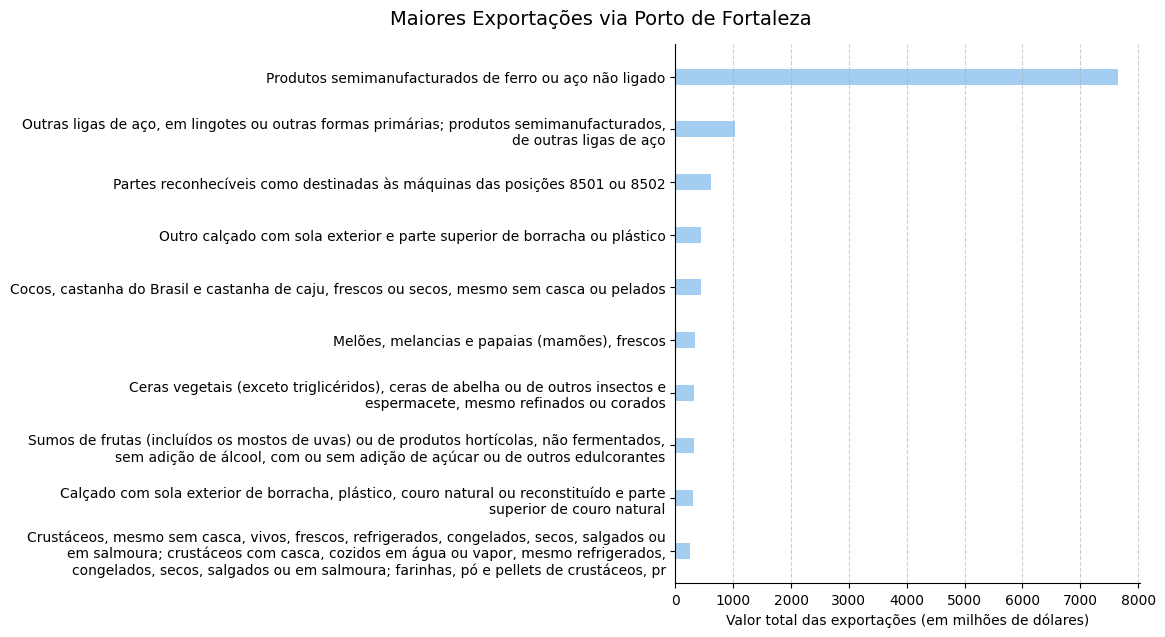

In [20]:
rotulos = df_2_fortaleza['categoria_do_produto'].head(10)
rotulos = [textwrap.fill(i, width =90) for i in rotulos] # para permitir quebrar as linhas dos nomes dos produtos

#plotando no gráfico para melhor visualização
plt.figure(figsize=(6, 7)) # tamanho da caixa da figura
plt.barh(
    rotulos,
    df_2_fortaleza['valor_total_usd'].head(10),
    color='#A3CEF1',
    height=0.30
)
plt.gca().invert_yaxis() # necessário para a correta ordem decrescente dos valores.

# usar esse método para título garante mais controle
plt.suptitle('Maiores Exportações via Porto de Fortaleza', 
             fontsize=14, 
            x=0, #garante que o titulo fique no meio da caixa
            y=0.93
            )

# remover as linhas de cima e da direita da "caixa" em que o gráfico é criado
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.6) # adicionar o grid para melhor visuzaliação
plt.yticks(fontsize=10) #controla o tamanho da fonte dos rótulos de dados

plt.xlabel("Valor total das exportações (em milhões de dólares)")

plt.show()

Curiosamente, os destaques são semelhantes ao porto do Pecém. A diferença é uma predominância ainda mais forte de produtos siderúrgicos. Outros tipos de produtos também se mantém semelhantes, como calçados, partes de maquinário e alimentos.

Conforme resultados das análises, não há diferenças relevantes entre os tipos de carga exportados no porto do Pecém e no porto de Fortaleza.

### Os parceiros emergentes

Quais países mais cresceram no total de exportações? Identificar esses novos destinos para as mercadorias estaduais tem grande valor. Por isso, esse trecho busca identificar países que tiveram crescimento econômico nas movimentações, fornecendo assim dados sobre a expansão da economia estadual e podendo orientar políticas públicas e acordos internacionais. Como a intenção é analisar crescimento recente, serão considerados apenas os anos completos de 2022 e 2024.

In [21]:
query = """ 
SELECT
    nomeclatura_pais.nome AS destino,  -- destino do produto
    SUM(IF(ano=2022, exportacao.valor_fob_dolar,0)) AS valor_2022,
    SUM(IF(ano=2024, exportacao.valor_fob_dolar,0)) AS valor_2024,
    SUM(exportacao.valor_fob_dolar) AS valor_total

FROM `basedosdados.br_me_comex_stat.ncm_exportacao` AS exportacao

-- esse join é para traduzir a UF de origem e permitir selecionar apenas o estado do Ceará
LEFT JOIN (SELECT DISTINCT sigla,nome  FROM `basedosdados.br_bd_diretorios_brasil.uf`) AS diretorio_sigla_uf_ncm 
  ON exportacao.sigla_uf_ncm = diretorio_sigla_uf_ncm.sigla

-- esse join é para traduzir o nome dos países
JOIN `basedosdados.br_bd_diretorios_mundo.pais` AS nomeclatura_pais   
  ON exportacao.sigla_pais_iso3 = nomeclatura_pais.sigla_pais_iso3

-- esse join serve para identificar a via de exportação e permitir a seleção apenas da via marítima
LEFT JOIN `basedosdados.br_me_comex_stat.dicionario` AS dic  
  ON exportacao.id_via = dic.chave
  AND dic.nome_coluna = 'id_via'
  AND dic.id_tabela = 'ncm_exportacao'

WHERE exportacao.ano IN (2022, 2024) -- limitador de 3 anos
AND diretorio_sigla_uf_ncm.nome = 'Ceará' -- limitador de exportações apenas do estado do Ceará 
AND dic.valor = 'Maritima'  -- limitador de exportações via marítima

GROUP BY  destino -- juntando todos os resultados de um país em uma única linha

ORDER BY valor_total DESC  -- países com maior valor em exportação primeiro
"""

df_4 = bd.read_sql(
    query,  # a query criada acima
    billing_project_id=project_id  # o id do projeto
)

df_4.head()

Downloading: 100%|██████████|


,destino,valor_2022,valor_2024,valor_total
0,Estados Unidos,586368259,648049880,1234418139
1,México,569571254,57415937,626987191
2,Espanha,139656547,19162712,158819259
3,Itália,104473220,41481844,145955064
4,Holanda,71565028,62532100,134097128


Existem países que são novos parceiros comerciais, tendo valores de exportação em 2024 mas não em 2022. Esses países são excluídos da análise para que se possa criar corretamente o porcentual de crescimento.

In [22]:
#tratamento de valores e criação de indicadores de crescimento

#aqui se removem os países que não tinham valor de exportação em 2022.
df_4 = df_4.drop(df_4[df_4["valor_2022"] == 0].index)

# aqui se cria a coluna com o % de crescimento como a relação entre o valor de exportações em 2024 e em 2022.
df_4['crescimento (%)'] = ((round(df_4['valor_2024'] / df_4['valor_2022'], 3))-1)*100 # razão arredondada com 2 casa decimais. Continua como decimal mas pode ser lida como porcentagem.

# ordenar o dataset em ordem decrescente de % de crescimento
df_4.sort_values(by="crescimento (%)",
                ascending=False, #ordem decrescente
                inplace=True
                )

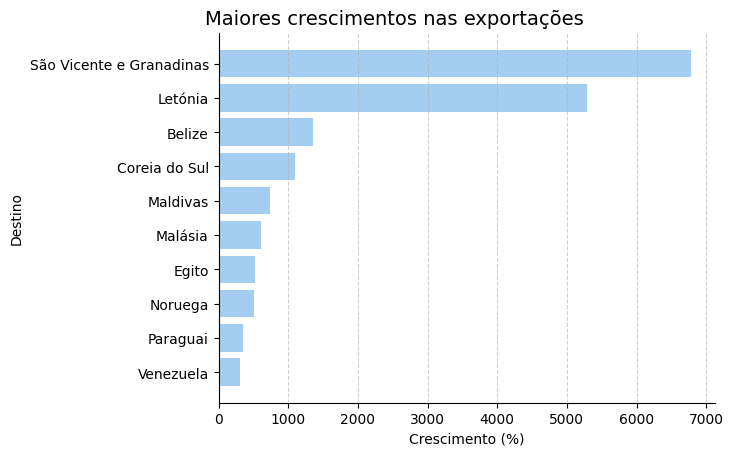

In [27]:
# plotar gráfico de barras horizontais
plt.barh(
    df_4['destino'].head(10),
    df_4['crescimento (%)'].head(10),
    color='#A3CEF1'
)

plt.gca().invert_yaxis() # necessário para a correta ordem decrescente dos valores.

# remover as linhas de cima e da direita da "caixa" em que o gráfico é criado
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='x', linestyle='--', alpha=0.6) # adicionar o grid para melhor visuzaliação

# usar esse método para título garante mais controle
plt.suptitle('Maiores crescimentos nas exportações', 
             fontsize=14, 
            x=0.4, #posição do título na caixa
            y=0.93
            )

plt.xlabel("Crescimento (%)")
plt.ylabel("Destino")
plt.show()

Nesse ponto nota-se a diversificação das movimentações de exportação do estado. Entre os maiores crescimentos comerciais tem-se desde pequenas economias locais até grande potencias econômicas mundiais. Cabe nota também que esses parceiros emergentes estão por todo o planeta, tendo representantes de todos os continentes entre os 10 maiores crescimentos.

### Conclusões Gerais

O estado do Ceará possui uma dominância da pauta exportadora no setor siderúrgico, com forte dependência de exportações para os Estados Unidos. As exportações se distribuem entre os portos do Pecém e de Fortaleza, sem grandes variações entre os tipos de carga destinadas a cada porto. Em contrapartida à dominância citada, novos parceiros comerciais vêm crescendo sua participação nas exportações do estado, com destaque para grandes esconomias mundiais como Coréia do Sul e Noruega.